=== Dataset Columns ===
Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='object')
LossRatio missing values: 381634
LossRatio column successfull

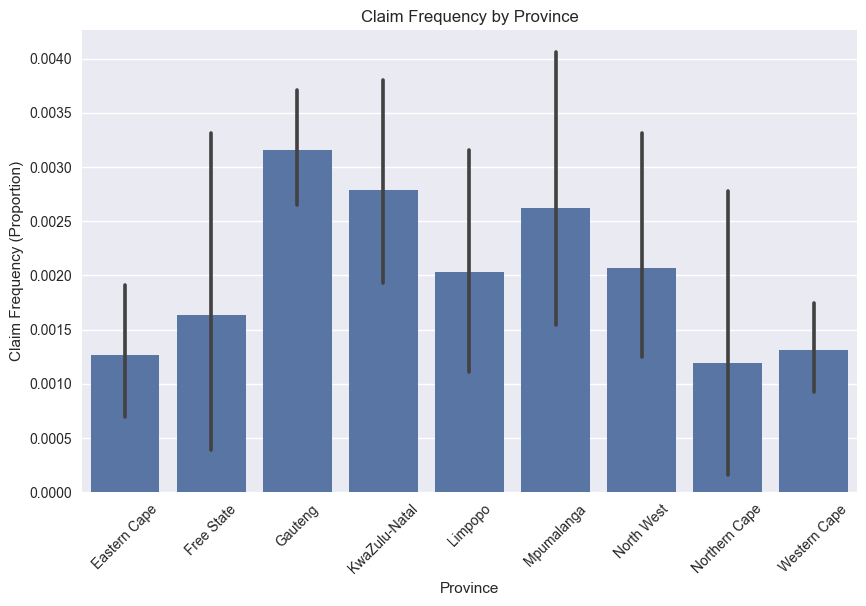

In [7]:

# Analysis code
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette('deep')

# Load DVC-tracked dataset
data = pd.read_csv('../data/MachineLearningRating_v3.txt', sep='|')

# Verify column names
print("=== Dataset Columns ===")
print(data.columns)

# Data Preprocessing
# Ensure TotalClaims and TotalPremium are numeric
data['TotalClaims'] = pd.to_numeric(data['TotalClaims'], errors='coerce')
data['TotalPremium'] = pd.to_numeric(data['TotalPremium'], errors='coerce')

# Calculate LossRatio with error handling
data['LossRatio'] = data['TotalClaims'] / data['TotalPremium'].replace(0, np.nan)
print(f"LossRatio missing values: {data['LossRatio'].isnull().sum()}")  # Check for missing values

data['TransactionMonth'] = pd.to_datetime(data['TransactionMonth'], errors='coerce')
data['CarAge'] = 2015 - data['RegistrationYear']
data['Margin'] = data['TotalPremium'] - data['TotalClaims']
data['HasClaim'] = (data['TotalClaims'] > 0).astype(int)

# Verify LossRatio column exists
if 'LossRatio' not in data.columns:
    print("Error: LossRatio column not created. Check TotalClaims and TotalPremium data.")
else:
    print("LossRatio column successfully created.")

# Metrics
# Claim Frequency: Proportion of policies with claims
claim_frequency = data.groupby(['Province', 'PostalCode', 'Gender'])['HasClaim'].mean().reset_index(name='ClaimFrequency')
# Claim Severity: Average claim amount for policies with claims
claim_severity = data[data['TotalClaims'] > 0].groupby(['Province', 'PostalCode', 'Gender'])['TotalClaims'].mean().reset_index(name='ClaimSeverity')
# Margin: Average margin per policy
margin = data.groupby('PostalCode')['Margin'].mean().reset_index(name='Margin')

# Data Segmentation: Select two postal codes with sufficient data
valid_zipcodes = data.groupby('PostalCode').filter(
    lambda x: x['Province'].notnull().sum() > 10 and x['HasClaim'].notnull().sum() > 10
)['PostalCode'].value_counts().head(2).index

if len(valid_zipcodes) < 2:
    print("Not enough postal codes with sufficient data for analysis.")
    equivalence_check = {}
    zip1, zip2 = None, None
else:
    zip1, zip2 = valid_zipcodes[0], valid_zipcodes[1]
    print(f"Selected PostalCodes: {zip1}, {zip2}")

    # Updated equivalence check function
    def check_equivalence(group_a, group_b, numerical_cols, categorical_cols):
        results = {}
        for col in numerical_cols:
            if col not in group_a.columns or col not in group_b.columns or group_a[col].dropna().empty or group_b[col].dropna().empty:
                results[f'{col}_p'] = None
            else:
                _, p = stats.mannwhitneyu(group_a[col].dropna(), group_b[col].dropna())
                results[f'{col}_p'] = p
        for col in categorical_cols:
            if col not in group_a.columns or col not in group_b.columns:
                results[f'{col}_p'] = None
            else:
                contingency = pd.crosstab(group_a[col], group_b[col])
                if contingency.empty or contingency.values.sum() < 5:
                    results[f'{col}_p'] = None
                else:
                    try:
                        _, p, _, _ = stats.chi2_contingency(contingency)
                        results[f'{col}_p'] = p
                    except ValueError:
                        results[f'{col}_p'] = None
        return results

    # Check for valid categorical columns
    categorical_cols = ['VehicleType', 'CoverType']
    available_categorical_cols = [col for col in categorical_cols if col in data.columns]
    if not available_categorical_cols:
        print("Warning: VehicleType and CoverType not found. Using Province as a fallback categorical column.")
        available_categorical_cols = ['Province']

    equivalence_check = check_equivalence(
        data[data['PostalCode'] == zip1], data[data['PostalCode'] == zip2],
        numerical_cols=['CarAge', 'CustomValueEstimate'],
        categorical_cols=available_categorical_cols
    )
    print("=== Equivalence Check for PostalCodes ===")
    print(equivalence_check)

# Statistical Tests
# H₀1: No risk differences across Province
province_groups_freq = [data[data['Province'] == p]['HasClaim'] for p in data['Province'].unique() if len(data[data['Province'] == p]['HasClaim'].dropna()) > 0]
province_groups_sev = [data[(data['Province'] == p) & (data['TotalClaims'] > 0)]['TotalClaims'] for p in data['Province'].unique() if len(data[(data['Province'] == p) & (data['TotalClaims'] > 0)]['TotalClaims'].dropna()) > 0]

anova_freq = stats.f_oneway(*province_groups_freq) if len(province_groups_freq) > 1 else (None, 1.0)
anova_sev = stats.f_oneway(*province_groups_sev) if len(province_groups_sev) > 1 else (None, 1.0)
h1_result = {
    'ClaimFrequency': ('Reject' if anova_freq[1] < 0.05 else 'Fail to Reject', anova_freq[1]),
    'ClaimSeverity': ('Reject' if anova_sev[1] < 0.05 else 'Fail to Reject', anova_sev[1])
}

# H₀2: No risk differences between PostalCode (zip1 vs. zip2)
if zip1 and zip2:
    contingency_zip = pd.crosstab(data[data['PostalCode'].isin([zip1, zip2])]['PostalCode'], data['HasClaim'])
    chi2_freq, p_freq = stats.chi2_contingency(contingency_zip)[0:2] if not contingency_zip.empty else (None, 1.0)
    sev_zip1 = data[(data['PostalCode'] == zip1) & (data['TotalClaims'] > 0)]['TotalClaims'].dropna()
    sev_zip2 = data[(data['PostalCode'] == zip2) & (data['TotalClaims'] > 0)]['TotalClaims'].dropna()
    u_sev, p_sev = stats.mannwhitneyu(sev_zip1, sev_zip2) if len(sev_zip1) > 0 and len(sev_zip2) > 0 else (None, 1.0)
    h2_result = {
        'ClaimFrequency': ('Reject' if p_freq < 0.05 else 'Fail to Reject', p_freq),
        'ClaimSeverity': ('Reject' if p_sev < 0.05 else 'Fail to Reject', p_sev)
    }
else:
    h2_result = {
        'ClaimFrequency': ('Fail to Reject', 1.0),
        'ClaimSeverity': ('Fail to Reject', 1.0)
    }

# H₀3: No Margin difference between PostalCode
if zip1 and zip2:
    margin_zip1 = data[data['PostalCode'] == zip1]['Margin'].dropna()
    margin_zip2 = data[data['PostalCode'] == zip2]['Margin'].dropna()
    u_margin, p_margin = stats.mannwhitneyu(margin_zip1, margin_zip2) if len(margin_zip1) > 0 and len(margin_zip2) > 0 else (None, 1.0)
    h3_result = ('Reject' if p_margin < 0.05 else 'Fail to Reject', p_margin)
else:
    h3_result = ('Fail to Reject', 1.0)

# H₀4: No risk difference between Gender
contingency_gender = pd.crosstab(data['Gender'], data['HasClaim'])
chi2_gender_freq, p_gender_freq = stats.chi2_contingency(contingency_gender)[0:2] if not contingency_gender.empty else (None, 1.0)
sev_male = data[(data['Gender'] == 'M') & (data['TotalClaims'] > 0)]['TotalClaims'].dropna()
sev_female = data[(data['Gender'] == 'F') & (data['TotalClaims'] > 0)]['TotalClaims'].dropna()
u_gender_sev, p_gender_sev = stats.mannwhitneyu(sev_male, sev_female) if len(sev_male) > 0 and len(sev_female) > 0 else (None, 1.0)
h4_result = {
    'ClaimFrequency': ('Reject' if p_gender_freq < 0.05 else 'Fail to Reject', p_gender_freq),
    'ClaimSeverity': ('Reject' if p_gender_sev < 0.05 else 'Fail to Reject', p_gender_sev)
}

# Report Results
print("\n=== Hypothesis Testing Results ===")
print("H₀1: No risk differences across Province")
print(f"Claim Frequency: {h1_result['ClaimFrequency']}")
print(f"Claim Severity: {h1_result['ClaimSeverity']}")
print("\nH₀2: No risk differences between PostalCode")
print(f"Claim Frequency: {h2_result['ClaimFrequency']}")
print(f"Claim Severity: {h2_result['ClaimSeverity']}")
print("\nH₀3: No Margin difference between PostalCode")
print(f"Margin: {h3_result}")
print("\nH₀4: No risk difference between Gender")
print(f"Claim Frequency: {h4_result['ClaimFrequency']}")
print(f"Claim Severity: {h4_result['ClaimSeverity']}")

# Business Recommendations
print("\n=== Business Recommendations ===")
if 'LossRatio' in data.columns:
    if h1_result['ClaimFrequency'][0] == 'Reject' or h1_result['ClaimSeverity'][0] == 'Reject':
        loss_ratio_prov = data.groupby('Province')['LossRatio'].mean().sort_values()
        if len(loss_ratio_prov) > 1 and loss_ratio_prov.iloc[0] != 0:  # Avoid division by zero
            print(f"Reject H₀1: Provinces show significant risk differences. {loss_ratio_prov.index[-1]} has a {loss_ratio_prov.iloc[-1]/loss_ratio_prov.iloc[0]:.2%} higher loss ratio than {loss_ratio_prov.index[0]}. Adjust premiums by province to reflect risk.")
        else:
            print("Reject H₀1: Provinces show significant risk differences, but loss ratio comparison is not possible due to insufficient data.")
else:
    print("LossRatio column missing. Skipping H₀1 business recommendation.")

if h2_result['ClaimFrequency'][0] == 'Reject' or h2_result['ClaimSeverity'][0] == 'Reject':
    print(f"Reject H₀2: PostalCodes {zip1} and {zip2} show risk differences. Target low-risk postal codes for reduced premiums to attract clients.")
if h3_result[0] == 'Reject':
    print(f"Reject H₀3: Margin differs between PostalCodes. Focus marketing on high-margin areas to maximize profitability.")
if h4_result['ClaimFrequency'][0] == 'Reject' or h4_result['ClaimSeverity'][0] == 'Reject':
    if 'LossRatio' in data.columns:
        loss_ratio_gender = data.groupby('Gender')['LossRatio'].mean()
        print(f"Reject H₀4: Gender shows risk differences. {loss_ratio_gender.idxmax()} has a higher loss ratio. Consider gender-based pricing adjustments.")
    else:
        print("Reject H₀4: Gender shows risk differences, but loss ratio comparison is not possible due to missing LossRatio column.")

# Visualization: Claim Frequency by Province
plt.figure(figsize=(10, 6))
sns.barplot(data=claim_frequency, x='Province', y='ClaimFrequency')
plt.title('Claim Frequency by Province')
plt.ylabel('Claim Frequency (Proportion)')
plt.xticks(rotation=45)
plt.show()

# Test for CI/CD
def test_hypothesis_results():
    assert h1_result['ClaimFrequency'][1] >= 0, "Invalid p-value for H₀1 Claim Frequency"
    assert h2_result['ClaimSeverity'][1] >= 0, "Invalid p-value for H₀2 Claim Severity"

if __name__ == "__main__":
    test_hypothesis_results()
